# 1.4.4 Smoothing Images

## Kernel Convolution

In [167]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [168]:
l=1
kernel = np.array([[0,-1,0],[-1,4,-1],[0,-1,0]],np.float32)

In [169]:
kernel

array([[ 0., -1.,  0.],
       [-1.,  4., -1.],
       [ 0., -1.,  0.]], dtype=float32)

In [170]:
img = np.random.randint(10, size=(12,12))
#img = np.ones((10,10),np.float32)

In [171]:
img

array([[5, 6, 7, 2, 3, 3, 4, 8, 7, 6, 7, 6],
       [0, 7, 5, 7, 4, 5, 0, 7, 4, 6, 6, 9],
       [3, 0, 3, 9, 8, 4, 0, 4, 6, 8, 1, 2],
       [4, 1, 4, 4, 1, 4, 5, 5, 0, 3, 4, 4],
       [7, 1, 6, 4, 9, 9, 5, 5, 2, 1, 8, 2],
       [0, 0, 8, 2, 6, 0, 2, 0, 0, 5, 7, 8],
       [7, 6, 6, 8, 1, 6, 1, 9, 8, 4, 3, 3],
       [1, 7, 6, 4, 3, 6, 3, 3, 4, 8, 5, 7],
       [6, 3, 6, 6, 4, 2, 5, 0, 0, 8, 5, 9],
       [1, 4, 4, 6, 0, 4, 6, 3, 6, 0, 2, 4],
       [1, 8, 0, 0, 5, 0, 1, 3, 6, 0, 6, 2],
       [4, 5, 4, 7, 8, 4, 1, 5, 9, 2, 9, 0]])

In [172]:
h,w=img.shape

In [173]:
print(h,w)

12 12


In [174]:
#[*range(-2,3)]

In [175]:
dst = np.zeros((h,w),dtype = int)

In [176]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i,j]=t        

In [177]:
img

array([[5, 6, 7, 2, 3, 3, 4, 8, 7, 6, 7, 6],
       [0, 7, 5, 7, 4, 5, 0, 7, 4, 6, 6, 9],
       [3, 0, 3, 9, 8, 4, 0, 4, 6, 8, 1, 2],
       [4, 1, 4, 4, 1, 4, 5, 5, 0, 3, 4, 4],
       [7, 1, 6, 4, 9, 9, 5, 5, 2, 1, 8, 2],
       [0, 0, 8, 2, 6, 0, 2, 0, 0, 5, 7, 8],
       [7, 6, 6, 8, 1, 6, 1, 9, 8, 4, 3, 3],
       [1, 7, 6, 4, 3, 6, 3, 3, 4, 8, 5, 7],
       [6, 3, 6, 6, 4, 2, 5, 0, 0, 8, 5, 9],
       [1, 4, 4, 6, 0, 4, 6, 3, 6, 0, 2, 4],
       [1, 8, 0, 0, 5, 0, 1, 3, 6, 0, 6, 2],
       [4, 5, 4, 7, 8, 4, 1, 5, 9, 2, 9, 0]])

In [178]:
dst

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,  17,  -4,   8,  -7,   9, -16,  12, -10,   0,   1,   0],
       [  0, -14,  -6,  14,  14,  -1, -13,  -2,   8,  16, -16,   0],
       [  0,  -5,   2,  -2, -21,  -3,   6,   6, -16,  -1,   0,   0],
       [  0, -10,   7,  -5,  16,  18,  -1,   8,   2, -14,  18,   0],
       [  0, -15,  18, -18,  12, -23,   2, -16, -15,   8,   4,   0],
       [  0,   4,  -4,  19, -19,  16, -16,  24,  15,  -8,  -7,   0],
       [  0,  12,   1,  -7,  -3,  10,  -3,  -4,  -3,  11,  -3,   0],
       [  0, -11,   5,   4,   5, -11,   9, -11, -18,  19,  -4,   0],
       [  0,   0,   0,  14, -19,   8,  11,  -3,  15, -16,  -7,   0],
       [  0,  22, -16, -18,  12, -14,  -6,  -3,   6, -14,  11,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]])

In [179]:
img = cv2.imread('lena.png', 0)

In [180]:
h,w=img.shape

In [181]:
dst = np.zeros((h-2*l,w-2*l),np.uint8)

In [182]:
for i in range(l,h-l):
    for j in range(l,w-l):
        t=0
        for p in range(-l,l+1):
            for q in range(-l,l+1):
                t += kernel[p+l,q+l]*img[i+p,j+q]
        dst[i-l,j-l]=t 

In [183]:
cv2.imshow('img',img)
cv2.imshow('dst',dst)
cv2.waitKey(0)
cv2.destroyAllWindows()

### Box blur

In [184]:
img1 = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

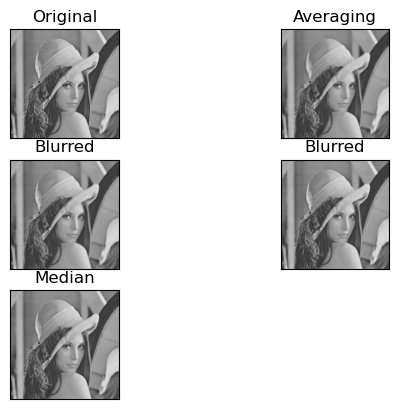

In [185]:
kernel = np.ones((5,5),np.float32)/25
dst = cv2.filter2D(img1,-1,kernel)
blur_1 = cv2.blur(img1,(5,5))
blur_2 = cv2.GaussianBlur(img1,(5,5),0)
median = cv2.medianBlur(img1,5)

plt.subplot(321),plt.imshow(img1),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(322),plt.imshow(dst),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.subplot(323),plt.imshow(blur_1),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.subplot(324),plt.imshow(blur_2),plt.title('Blurred')
plt.xticks([]), plt.yticks([])
plt.subplot(325),plt.imshow(blur_2),plt.title('Median')
plt.xticks([]), plt.yticks([])
plt.show()